<a href="https://colab.research.google.com/github/Praveenraju10/15_days_workshop/blob/main/Day2/Day2%202nd.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [59]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("all libraries are imported successfully")
print(f"Pandas version is {pd.__version__}")
print(f"SQLite3 version is {sqlite3.version}")

all libraries are imported successfully
Pandas version is 2.2.2
SQLite3 version is 2.6.0


In [60]:
df=pd.read_csv('student_performance.csv')
print(f"Dataset loaded:{df.shape[0]} students, {df.shape[1]} columns")
print(f"Columns:{df.columns.to_list()}")
df.head(3)

Dataset loaded:30 students, 13 columns
Columns:['student_id', 'name', 'age', 'gender', 'department', 'semester', 'math_score', 'science_score', 'english_score', 'programming_score', 'attendance_percentage', 'city', 'admission_year']


,student_id,name,age,gender,department,semester,math_score,science_score,english_score,programming_score,attendance_percentage,city,admission_year
0,1001,Aarav Sharma,19,Male,Computer Science,2,85,78,72,91,92,Mumbai,2023
1,1002,Priya Patel,20,Female,Computer Science,2,76,82,88,79,87,Ahmedabad,2023
2,1003,Rohit Verma,19,Male,Electronics,2,65,74,61,55,78,Delhi,2023


In [61]:
conn=sqlite3.connect('college.db')
cursor=conn.cursor()
df.to_sql(
    'students',
    conn,
    if_exists='replace',
    index=False
)

cursor.execute("SELECT COUNT(*) FROM students")

count=cursor.fetchone()[0]
print(f"Number of students in the database:{count}")


Number of students in the database:30


In [62]:
def run_query(sql, description="student"):
  if description:
    print(f"{description}")

  result=pd.read_sql_query(sql, conn)
  return result
print("Helper function 'run_query' defined successfully")
print("Usage: run_quey(sql_string, description_label)")

Helper function 'run_query' defined successfully
Usage: run_quey(sql_string, description_label)


In [63]:
query1="""SELECT student_id from students  Limit 5"""

result1=run_query(query1, "First 10 students")
result1

First 10 students


,student_id
0,1001
1,1002
2,1003
3,1004
4,1005


In [64]:
query2="""select name from students where name between 'A' and 'F'"""

result2=run_query(query2)
result2

student


,name
0,Aarav Sharma
1,Arjun Nair
2,Divya Singh
3,Ananya Das
4,Ajay Tiwari
5,Deepak Chauhan
6,Amit Bose
7,Akanksha Yadav


In [65]:
query3="""select department,count(*) as num_students,round(avg(math_score),2) as avg_math, round(avg(science_score),2) as avg_science, round(avg(programming_score),2) as avg_programmming, round(avg(attendance_percentage),2)as avg_attendance from students group by department order by avg_math desc"""
result3=run_query(query3)
print(result3.to_string(index=False))

student
      department  num_students  avg_math  avg_science  avg_programmming  avg_attendance
Computer Science            13     85.62        84.46             89.23           90.69
      Mechanical             6     71.00        76.50             49.33           83.50
     Electronics             6     71.00        74.17             61.50           80.33
           Civil             5     63.40        66.60             40.60           74.60


In [66]:
query4="""select department,count(*) as num_students,round(avg(math_score),2) as avg_math from students group by department having avg_math>70 order by avg_math desc"""
result4=run_query(query4)
result4

student


,department,num_students,avg_math
0,Computer Science,13,85.62
1,Mechanical,6,71.00
2,Electronics,6,71.00


In [67]:
query5="""select gender,count(*) as num_students,round(avg(math_score),2) as avg_math, round(avg(science_score),2) as avg_science, round(avg(programming_score),2) as avg_programmming, round(avg(attendance_percentage),2)as avg_attendance from students group by gender"""
result5=run_query(query5)
result5


student


,gender,num_students,avg_math,avg_science,avg_programmming,avg_attendance
0,Female,15,78.47,81.20,70.2,88.53
1,Male,15,73.67,74.47,65.0,80.47


In [68]:
### matplotlib]
import pandas as pd


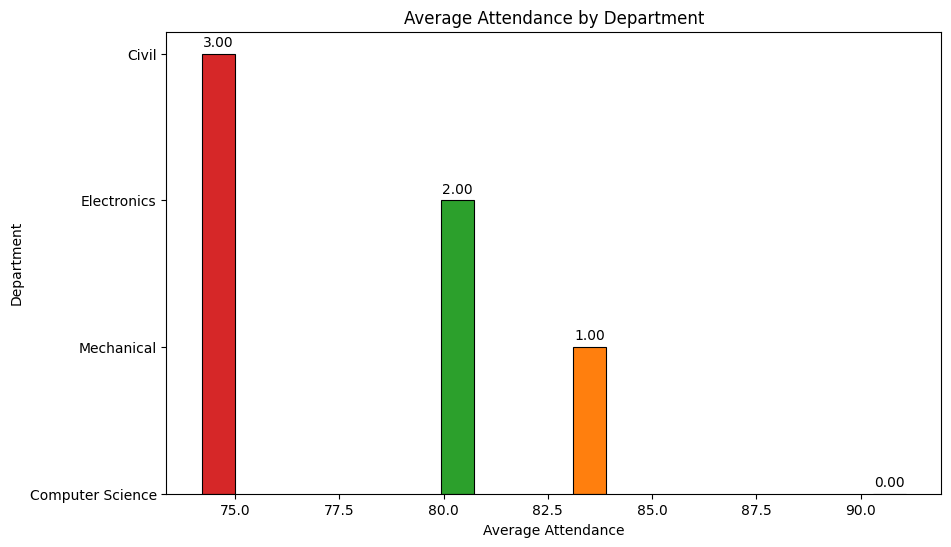

In [69]:
chart1_sql = """
SELECT department,
       ROUND(AVG(attendance_percentage),2) AS avg_attendance
FROM students
GROUP BY department
ORDER BY avg_attendance DESC
"""

chart1_data = pd.read_sql_query(chart1_sql, conn)

fig, ax = plt.subplots(figsize=(10,6))

bar_color = ['tab:blue','tab:orange','tab:green','tab:red']

bars = ax.bar(

    chart1_data['avg_attendance'],
    chart1_data['department'],
    color=bar_color,
    edgecolor='black',
    linewidth=0.8
)

for bar in bars:
    height = bar.get_height()

    ax.annotate(
        f'{height:.2f}',
        xy=(bar.get_x() + bar.get_width()/2, height),
        xytext=(0,3),
        textcoords='offset points',
        ha='center',
        va='bottom'
    )

ax.set_ylabel('Department')
ax.set_xlabel('Average Attendance')
ax.set_title('Average Attendance by Department')

plt.show()

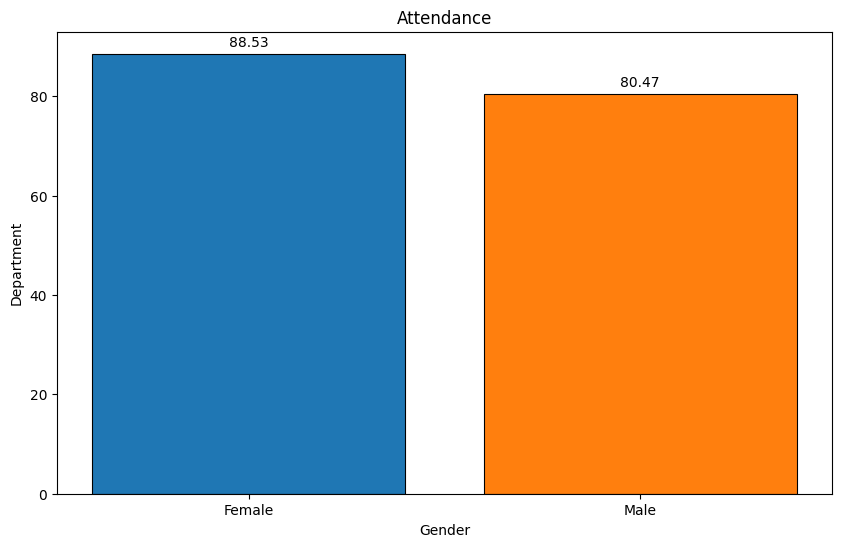

In [70]:
chart1_sql = """
SELECT gender,
       ROUND(AVG(attendance_percentage),2) AS avg_attendance
FROM students
GROUP BY gender
ORDER BY avg_attendance DESC
"""

chart1_data = pd.read_sql_query(chart1_sql, conn)

fig, ax = plt.subplots(figsize=(10,6))

bar_color = ['tab:blue','tab:orange','tab:green','tab:red']

bars = ax.bar(

    chart1_data['gender'],
    chart1_data['avg_attendance'],
    color=bar_color,
    edgecolor='black',
    linewidth=0.8
)

for bar in bars:
    height = bar.get_height()

    ax.annotate(
        f'{height:.2f}',
        xy=(bar.get_x() + bar.get_width()/2, height),
        xytext=(0,3),
        textcoords='offset points',
        ha='center',
        va='bottom'
    )

ax.set_ylabel('Department')
ax.set_xlabel('Gender')
ax.set_title('Attendance')

plt.show()

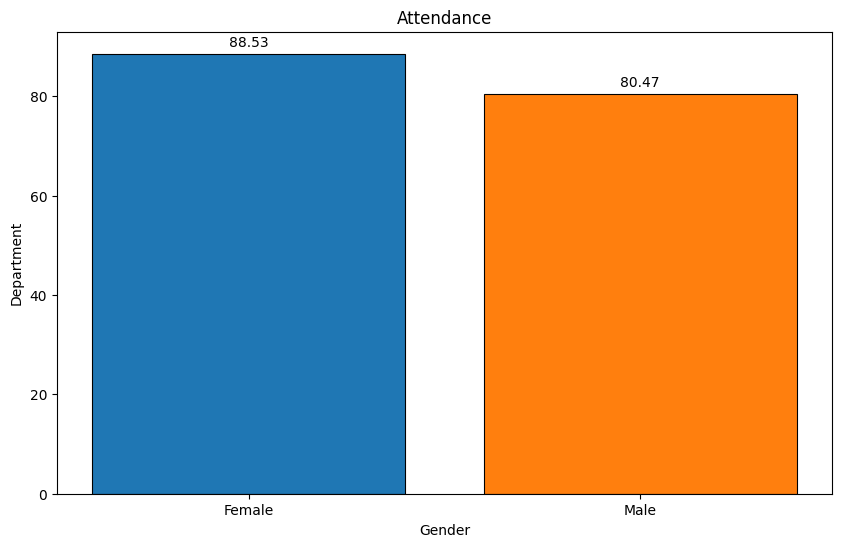

In [71]:
chart1_sql = """
SELECT gender,
       ROUND(AVG(attendance_percentage),2) AS avg_attendance
FROM students
GROUP BY gender
ORDER BY avg_attendance DESC
"""

chart1_data = pd.read_sql_query(chart1_sql, conn)

fig, ax = plt.subplots(figsize=(10,6))

bar_color = ['tab:blue','tab:orange','tab:green','tab:red']

bars = ax.bar(

    chart1_data['gender'],
    chart1_data['avg_attendance'],
    color=bar_color,
    edgecolor='black',
    linewidth=0.8
)

for bar in bars:
    height = bar.get_height()

    ax.annotate(
        f'{height:.2f}',
        xy=(bar.get_x() + bar.get_width()/2, height),
        xytext=(0,3),
        textcoords='offset points',
        ha='center',
        va='bottom'
    )

ax.set_ylabel('Department')
ax.set_xlabel('Gender')
ax.set_title('Attendance')

plt.show()

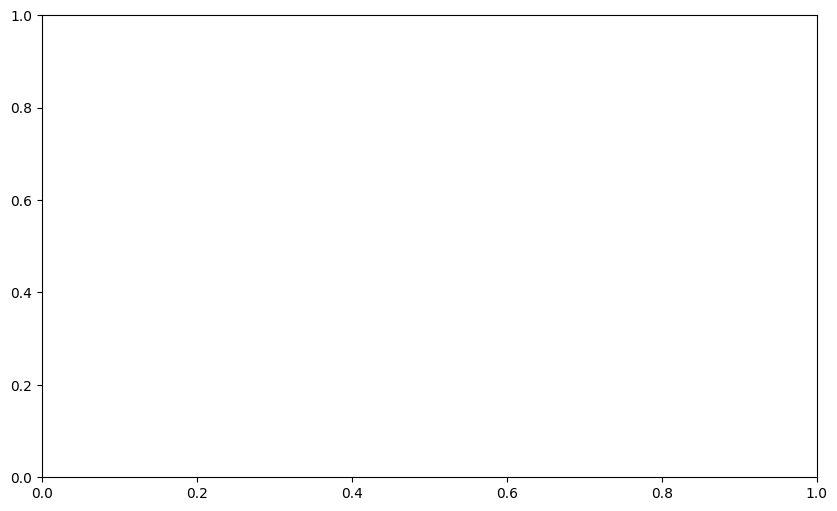

In [72]:
chart4_sql="""select department,count(*) as num_students from students group by department order by num_students desc"""

chart4_data=pd.read_sql_query(chart4_sql,conn)

labels=chart4_data['department'].tolist()
sizes=chart4_data['num_students'].tolist()
colors=['#4FC3F7', '#008978','#E67E22','#8E44AD']
explode=[0.06,0,0,0]

fig, ax=plt.subplots(figsize=(10,6))


In [76]:
chart5_sql="""select gender,round(avg(programming_score),2) as avg_prog from students group by gender having gender='Female'"""
chart5=pd.read_sql_query(chart5_sql,conn)
chart5

,gender,avg_prog
0,Female,70.2


In [80]:
chart6_sql="""select department,round(avg(attendance_percentage),2) as avg_atten from students group by department having avg_atten>85"""
chart6=pd.read_sql_query(chart6_sql,conn)
chart6

,department,avg_atten
0,Computer Science,90.69


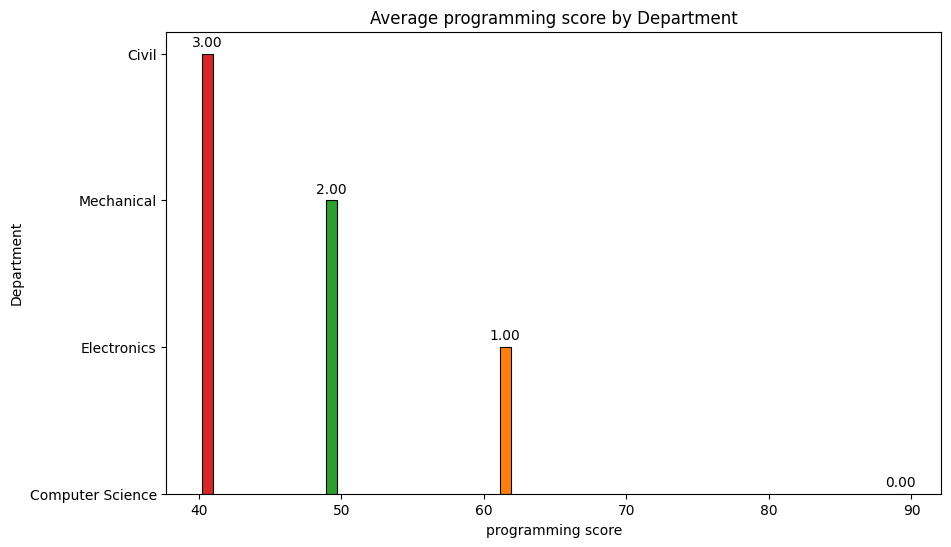

In [86]:
chart1_sql = """
SELECT department,
       ROUND(AVG(programming_score),2) AS avg_program
FROM students
GROUP BY department
ORDER BY avg_program DESC
"""

chart1_data = pd.read_sql_query(chart1_sql, conn)

fig, ax = plt.subplots(figsize=(10,6))

bar_color = ['tab:blue','tab:orange','tab:green','tab:red']

bars = ax.bar(
    chart1_data['avg_program'],
    chart1_data['department'],

    color=bar_color,
    edgecolor='black',
    linewidth=0.8
)

for bar in bars:
    height = bar.get_height()

    ax.annotate(
        f'{height:.2f}',
        xy=(bar.get_x() + bar.get_width()/2, height),
        xytext=(0,3),
        textcoords='offset points',
        ha='center',
        va='bottom'
   )

ax.set_ylabel('Department')
ax.set_xlabel('programming score')
ax.set_title('Average programming score by Department')

plt.show()